In [ ]:
!pip install tensorflow matplotlib scikit-learn pillow streamlit numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.2 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.9 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import matplotlib
import sklearn
import PIL
import streamlit
import numpy
import pandas

print("All libraries installed successfully!")

All libraries installed successfully!


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
print(tf.__version__)

2.20.0


In [5]:
train_dir = "dataset/train"
valid_dir = "dataset/valid"
test_dir = "dataset/test"

In [6]:
import os

print(os.listdir())

['.config', 'sample_data']


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshwalia/birds-vs-drone-dataset")

print("Path to dataset files:", path)

100%|██████████| 78.1M/78.1M [00:04<00:00, 16.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harshwalia/birds-vs-drone-dataset/versions/1


In [8]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/harshwalia/birds-vs-drone-dataset/versions/1"

print(os.listdir(dataset_path))

['BirdVsDrone']


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_dir = dataset_path + "/BirdVsDrone/train"
valid_dir = dataset_path + "/BirdVsDrone/valid"
test_dir = dataset_path + "/BirdVsDronee/test"

In [11]:
print(os.listdir(dataset_path + "/BirdVsDrone"))

['Birds', 'Drones']


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = dataset_path + "/BirdVsDrone"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 662 images belonging to 2 classes.
Found 164 images belonging to 2 classes.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [28]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9350 - loss: 0.1663 - val_accuracy: 0.9512 - val_loss: 0.1118
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9396 - loss: 0.1493 - val_accuracy: 0.9390 - val_loss: 0.1400
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9517 - loss: 0.1261 - val_accuracy: 0.9634 - val_loss: 0.1114


In [19]:
test_loss, test_acc = model.evaluate(valid_generator)

print("Validation Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9451 - loss: 0.1271
Validation Accuracy: 0.9451219439506531


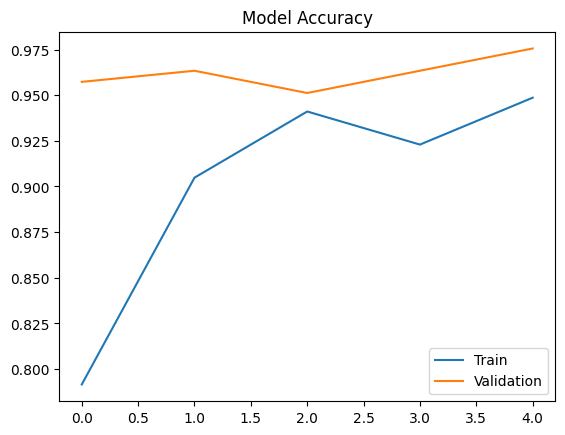

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

In [29]:
model.save("bird_drone_model.keras")

In [22]:
test_loss, test_acc = model.evaluate(valid_generator)

print("Validation Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9451 - loss: 0.1465
Validation Accuracy: 0.9451219439506531


In [24]:
predictions = model.predict(valid_generator)

6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


In [25]:
predicted_classes = (predictions > 0.5).astype(int)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
true_classes = valid_generator.classes
print(classification_report(true_classes, predicted_classes))
print(confusion_matrix(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.47      0.46      0.46        79
           1       0.51      0.53      0.52        85

    accuracy                           0.49       164
   macro avg       0.49      0.49      0.49       164
weighted avg       0.49      0.49      0.49       164

[[36 43]
 [40 45]]


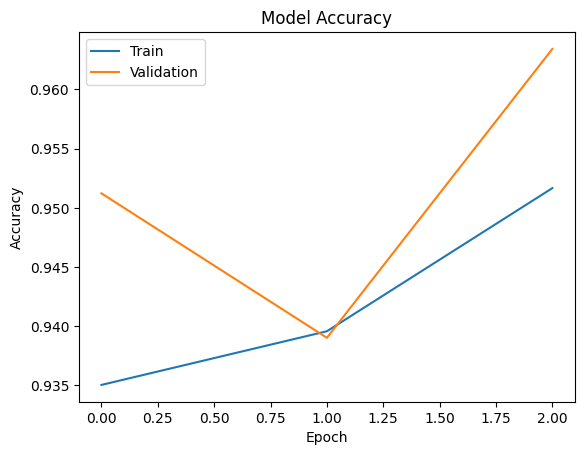

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

In [33]:
print(train_generator.class_indices)

{'Birds': 0, 'Drones': 1}
